In [ ]:
import numpy as np
import os
import xml.etree.ElementTree as ET
from PIL import Image  # Hanya untuk load image, alternatif bisa pakai matplotlib
import math
import pickle

IMAGES_DIR = '/Users/finanazwa/Downloads/archive (4)/images'
ANNOTATIONS_DIR = '/Users/finanazwa/Downloads/archive (4)/annotations'

def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    filename = root.find('filename').text
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)
    
    objects = []
    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')
        objects.append({
            'label': label,
            'x': int(bbox.find('xmin').text),
            'y': int(bbox.find('ymin').text),
            'w': int(bbox.find('xmax').text) - int(bbox.find('xmin').text),
            'h': int(bbox.find('ymax').text) - int(bbox.find('ymin').text)
        })
    
    return {
        'filename': filename,
        'width': width,
        'height': height,
        'objects': objects
    }

def load_dataset(max_images=50):
    xml_files = sorted([f for f in os.listdir(ANNOTATIONS_DIR) 
                       if f.endswith('.xml')])[:max_images]
    
    dataset = []
    for xml_file in xml_files:
        xml_path = os.path.join(ANNOTATIONS_DIR, xml_file)
        ann = parse_voc_xml(xml_path)
        
        base = os.path.splitext(ann['filename'])[0]
        img_path = None
        for ext in ['.png', '.jpg', '.jpeg']:
            test = os.path.join(IMAGES_DIR, base + ext)
            if os.path.exists(test):
                img_path = test
                break
        
        if img_path:
            dataset.append({
                'img_path': img_path,
                'annotation': ann
            })
    
    return dataset

In [ ]:
def load_image(img_path):
    img = Image.open(img_path)
    img_array = np.array(img)

    if len(img_array.shape) == 3:
        # Grayscale = 0.299*R + 0.587*G + 0.114*B
        gray = (0.299 * img_array[:,:,0] + 
                0.587 * img_array[:,:,1] + 
                0.114 * img_array[:,:,2]).astype(np.float32)
    else:
        gray = img_array.astype(np.float32)
    
    return gray

def resize_image(image, new_height, new_width):
    old_height, old_width = image.shape
    result = np.zeros((new_height, new_width), dtype=np.float32)
    
    for i in range(new_height):
        for j in range(new_width):
            y = i * (old_height - 1) / (new_height - 1)
            x = j * (old_width - 1) / (new_width - 1)
            
            y0, x0 = int(y), int(x)
            y1, x1 = min(y0 + 1, old_height - 1), min(x0 + 1, old_width - 1)
            
            dy, dx = y - y0, x - x0
            
            result[i, j] = (image[y0, x0] * (1 - dx) * (1 - dy) +
                           image[y0, x1] * dx * (1 - dy) +
                           image[y1, x0] * (1 - dx) * dy +
                           image[y1, x1] * dx * dy)
    
    return result

def normalize_image(image):
    """Normalisasi ke range [0, 1]"""
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val > 0:
        return (image - min_val) / (max_val - min_val)
    return image

In [ ]:
def compute_gradients(image):
    h, w = image.shape

    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]])
    sobel_y = np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]])
    
    grad_x = np.zeros_like(image)
    grad_y = np.zeros_like(image)

    for i in range(1, h-1):
        for j in range(1, w-1):
            patch = image[i-1:i+2, j-1:j+2]
            grad_x[i, j] = np.sum(patch * sobel_x)
            grad_y[i, j] = np.sum(patch * sobel_y)
    
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    orientation = np.arctan2(grad_y, grad_x) * (180 / np.pi) % 180  # 0-180 degrees
    
    return magnitude, orientation

def compute_hog_features(image, cell_size=8, block_size=2, bins=9):
    h, w = image.shape

    magnitude, orientation = compute_gradients(image)

    cell_h = h // cell_size
    cell_w = w // cell_size

    cell_histograms = np.zeros((cell_h, cell_w, bins))
    
    bin_width = 180 / bins
    
    for i in range(cell_h):
        for j in range(cell_w):
            mag_cell = magnitude[i*cell_size:(i+1)*cell_size, 
                                j*cell_size:(j+1)*cell_size]
            ori_cell = orientation[i*cell_size:(i+1)*cell_size, 
                                  j*cell_size:(j+1)*cell_size]
            
            for y in range(cell_size):
                for x in range(cell_size):
                    if i*cell_size + y >= h or j*cell_size + x >= w:
                        continue
                    
                    ori = ori_cell[y, x]
                    mag = mag_cell[y, x]

                    bin_idx = ori / bin_width
                    bin_low = int(bin_idx) % bins
                    bin_high = (bin_low + 1) % bins
                    weight_high = bin_idx - int(bin_idx)
                    weight_low = 1 - weight_high
                    
                    cell_histograms[i, j, bin_low] += mag * weight_low
                    cell_histograms[i, j, bin_high] += mag * weight_high

    block_h = cell_h - block_size + 1
    block_w = cell_w - block_size + 1
    
    features = []
    
    for i in range(block_h):
        for j in range(block_w):
            block = cell_histograms[i:i+block_size, j:j+block_size, :]
            block_vector = block.flatten()

            norm = np.sqrt(np.sum(block_vector**2) + 1e-6)
            block_vector = block_vector / norm
            
            features.extend(block_vector)
    
    return np.array(features)

In [ ]:
class SlidingWindowDetector:
    def __init__(self, window_size=(64, 64), step_size=16, scales=[1.0, 0.8, 0.6, 0.5]):
        self.window_size = window_size  # (height, width)
        self.step_size = step_size
        self.scales = scales
        self.classifier = None
        self.scaler_mean = None
        self.scaler_std = None
    
    def extract_features(self, window):

        if window.shape != self.window_size:
            window = resize_image(window, self.window_size[0], self.window_size[1])
        
        window = normalize_image(window)
        
        features = compute_hog_features(window, cell_size=8, block_size=2, bins=9)
        
        return features
    
    def train(self, positive_samples, negative_samples):
        print("Extracting features for positive samples...")
        X_pos = []
        for img in positive_samples:
            feat = self.extract_features(img)
            X_pos.append(feat)
        
        print("Extracting features for negative samples...")
        X_neg = []
        for img in negative_samples:
            feat = self.extract_features(img)
            X_neg.append(feat)
        
        X_pos = np.array(X_pos)
        X_neg = np.array(X_neg)
        
        X = np.vstack([X_pos, X_neg])
        y = np.hstack([np.ones(len(X_pos)), -np.ones(len(X_neg))])
        
        self.scaler_mean = np.mean(X, axis=0)
        self.scaler_std = np.std(X, axis=0) + 1e-8
        X = (X - self.scaler_mean) / self.scaler_std
        
        print("Training SVM...")
        self.classifier = self._train_svm(X, y, epochs=1000, lr=0.01, C=1.0)
        
        scores = np.dot(X, self.classifier)
        predictions = np.where(scores > 0, 1, -1)
        accuracy = np.mean(predictions == y)
        print(f"Training accuracy: {accuracy:.4f}")
        
        return self
    
    def _train_svm(self, X, y, epochs=1000, lr=0.01, C=1.0):
        n_samples, n_features = X.shape
        weights = np.zeros(n_features)
        bias = 0
        
        for epoch in range(epochs):

            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for i in range(n_samples):
                xi = X_shuffled[i]
                yi = y_shuffled[i]
                
                if yi * (np.dot(weights, xi) + bias) < 1:
                    weights = weights - lr * weights + lr * C * yi * xi
                    bias = bias + lr * C * yi
                else:
                    weights = weights - lr * weights
            
            if epoch % 100 == 0:
                scores = np.dot(X, weights) + bias
                loss = np.mean(np.maximum(0, 1 - y * scores)) + 0.5 * np.sum(weights**2)
                print(f"  Epoch {epoch}, Loss: {loss:.4f}")
        
        self.bias = bias
        return weights
    
    def predict(self, features):
        if self.scaler_mean is not None:
            features = (features - self.scaler_mean) / self.scaler_std
        
        score = np.dot(features, self.classifier) + self.bias
        return score
    
    def detect(self, image, threshold=0.5):
        detections = []
        original_h, original_w = image.shape
        
        for scale in self.scales:

            if scale != 1.0:
                new_h = int(original_h * scale)
                new_w = int(original_w * scale)
                scaled_image = resize_image(image, new_h, new_w)
            else:
                scaled_image = image
                new_h, new_w = original_h, original_w
            
            h, w = scaled_image.shape
            win_h, win_w = self.window_size

            for y in range(0, h - win_h, self.step_size):
                for x in range(0, w - win_w, self.step_size):
                    window = scaled_image[y:y+win_h, x:x+win_w]
                    
                    features = self.extract_features(window)
                    score = self.predict(features)
                    
                    if score > threshold:
                        orig_x = int(x / scale)
                        orig_y = int(y / scale)
                        orig_w = int(win_w / scale)
                        orig_h = int(win_h / scale)
                        
                        detections.append({
                            'x': orig_x,
                            'y': orig_y,
                            'w': orig_w,
                            'h': orig_h,
                            'score': float(score),
                            'scale': scale
                        })
        
        return detections

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1['x'], box2['x'])
    y1 = max(box1['y'], box2['y'])
    x2 = min(box1['x'] + box1['w'], box2['x'] + box2['w'])
    y2 = min(box1['y'] + box1['h'], box2['y'] + box2['h'])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    area1 = box1['w'] * box1['h']
    area2 = box2['w'] * box2['h']
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

def non_max_suppression(detections, iou_threshold=0.5):
    if not detections:
        return []
    
    sorted_dets = sorted(detections, key=lambda x: x['score'], reverse=True)
    
    keep = []
    while sorted_dets:
        best = sorted_dets[0]
        keep.append(best)
        
        remaining = []
        for det in sorted_dets[1:]:
            if compute_iou(best, det) < iou_threshold:
                remaining.append(det)
        
        sorted_dets = remaining
    
    return keep

In [ ]:
def prepare_training_data(dataset, window_size=(64, 64)):
    positive_samples = []
    negative_samples = []
    
    print("Preparing training data...")
    
    for item in dataset:
        img = load_image(item['img_path'])
        h, w = img.shape
        ann = item['annotation']

        for obj in ann['objects']:
            x, y, bw, bh = obj['x'], obj['y'], obj['w'], obj['h']

            x = max(0, x)
            y = max(0, y)
            bw = min(bw, w - x)
            bh = min(bh, h - y)
            
            if bw > 10 and bh > 10:
                face_patch = img[y:y+bh, x:x+bw]
                face_resized = resize_image(face_patch, window_size[0], window_size[1])
                positive_samples.append(face_resized)

        num_negatives = len(ann['objects']) * 3  # 3x negative samples
        
        for _ in range(num_negatives):

            rw = np.random.randint(window_size[0]//2, min(window_size[0]*2, w))
            rh = np.random.randint(window_size[1]//2, min(window_size[1]*2, h))
            rx = np.random.randint(0, max(1, w - rw))
            ry = np.random.randint(0, max(1, h - rh))
            
            overlap = False
            for obj in ann['objects']:
                iou = compute_iou(
                    {'x': rx, 'y': ry, 'w': rw, 'h': rh},
                    {'x': obj['x'], 'y': obj['y'], 'w': obj['w'], 'h': obj['h']}
                )
                if iou > 0.1:
                    overlap = True
                    break
            
            if not overlap:
                neg_patch = img[ry:ry+rh, rx:rx+rw]
                neg_resized = resize_image(neg_patch, window_size[0], window_size[1])
                negative_samples.append(neg_resized)
    
    print(f"Positive samples: {len(positive_samples)}")
    print(f"Negative samples: {len(negative_samples)}")
    
    return positive_samples, negative_samples

def evaluate_detections(detections, ground_truths, iou_threshold=0.5):

    if not detections or not ground_truths:
        return 0, 0, 0, 0
    
    matched_gt = set()
    true_positives = 0
    ious = []
    
    for det in detections:
        best_iou = 0
        best_gt_idx = -1
        
        for i, gt in enumerate(ground_truths):
            if i in matched_gt:
                continue
            
            iou = compute_iou(det, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = i
        
        if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
            true_positives += 1
            matched_gt.add(best_gt_idx)
            ious.append(best_iou)
    
    false_positives = len(detections) - true_positives
    false_negatives = len(ground_truths) - len(matched_gt)
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    avg_iou = np.mean(ious) if ious else 0
    
    return precision, recall, f1, avg_iou

In [ ]:
def main():
    # Load dataset
    print("Loading dataset...")
    dataset = load_dataset(max_images=50)
    
    if not dataset:
        print("Empty Dataset.")
        return
    
    print(f"Loaded {len(dataset)} images")

    split_idx = int(len(dataset) * 0.8)
    train_data = dataset[:split_idx]
    test_data = dataset[split_idx:]
    
    print(f"Train: {len(train_data)}, Test: {len(test_data)}")

    pos_samples, neg_samples = prepare_training_data(train_data, window_size=(64, 64))
    
    if len(pos_samples) == 0:
        print("Tidak ada positive samples!")
        return

    detector = SlidingWindowDetector(
        window_size=(64, 64),
        step_size=16,
        scales=[1.0, 0.8, 0.6]
    )
    
    detector.train(pos_samples, neg_samples)

    print("\n" + "="*50)
    print("EVALUATION ON TEST SET")
    print("="*50)
    
    all_precisions = []
    all_recalls = []
    all_f1s = []
    all_ious = []
    
    for idx, item in enumerate(test_data[:5]):  # Test 5 gambar pertama
        print(f"\nTesting image {idx+1}/{min(5, len(test_data))}: {item['annotation']['filename']}")
        
        img = load_image(item['img_path'])
        ground_truths = item['annotation']['objects']

        detections = detector.detect(img, threshold=0.3)
        print(f"  Raw detections: {len(detections)}")

        final_detections = non_max_suppression(detections, iou_threshold=0.3)
        print(f"  After NMS: {len(final_detections)}")
        
        precision, recall, f1, avg_iou = evaluate_detections(
            final_detections, ground_truths, iou_threshold=0.5
        )
        
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  Average IoU: {avg_iou:.4f}")
        
        all_precisions.append(precision)
        all_recalls.append(recall)
        all_f1s.append(f1)
        all_ious.append(avg_iou)

    print("\n" + "="*50)
    print("SUMMARY")
    print("="*50)
    print(f"Average Precision: {np.mean(all_precisions):.4f}")
    print(f"Average Recall: {np.mean(all_recalls):.4f}")
    print(f"Average F1-Score: {np.mean(all_f1s):.4f}")
    print(f"Average IoU: {np.mean(all_ious):.4f}")

if __name__ == "__main__":
    main()

Loading dataset...
Loaded 50 images
Train: 40, Test: 10
Preparing training data...
Positive samples: 182
Negative samples: 386
Extracting features for positive samples...
Extracting features for negative samples...
Training SVM...
  Epoch 0, Loss: 0.7080
  Epoch 100, Loss: 0.9725
  Epoch 200, Loss: 0.5852
  Epoch 300, Loss: 0.7016
  Epoch 400, Loss: 1.0623
  Epoch 500, Loss: 0.6841
  Epoch 600, Loss: 0.8925
  Epoch 700, Loss: 0.7825
  Epoch 800, Loss: 0.9418
  Epoch 900, Loss: 1.3735
Training accuracy: 0.8856

EVALUATION ON TEST SET

Testing image 1/5: maksssksksss134.png
  Raw detections: 19
  After NMS: 9
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  Average IoU: 0.0000

Testing image 2/5: maksssksksss135.png
  Raw detections: 108
  After NMS: 17
  Precision: 0.0588
  Recall: 0.5000
  F1-Score: 0.1053
  Average IoU: 0.6341

Testing image 3/5: maksssksksss136.png
  Raw detections: 24
  After NMS: 10
  Precision: 0.1000
  Recall: 1.0000
  F1-Score: 0.1818
  Average IoU: 0.6

The model achieves a relatively high training accuracy of 88.56%, but its performance on the test set is very poor, with an average F1-score of only 0.0961. This indicates strong overfitting, where the model learns the training data well but fails to generalize to new images. The evaluation metrics show a clear imbalance between precision (0.0532) and recall (0.5000), meaning the model is able to detect many actual objects (moderate recall) but produces a large number of false positives (very low precision). This suggests that the classifier tends to over-detect and lacks a strong decision boundary.

In terms of IoU, IoU of 0.3872 indicates moderate performance, with some images achieving IoU values above 0.6, showing that bounding boxes can be reasonably accurate when detections are correct. However, several images have IoU equal to 0, meaning the model completely fails to detect objects in those cases. Overall, while the model demonstrates some ability to localize objects, its detection reliability is low due to excessive false positives and inconsistent performance across test images.

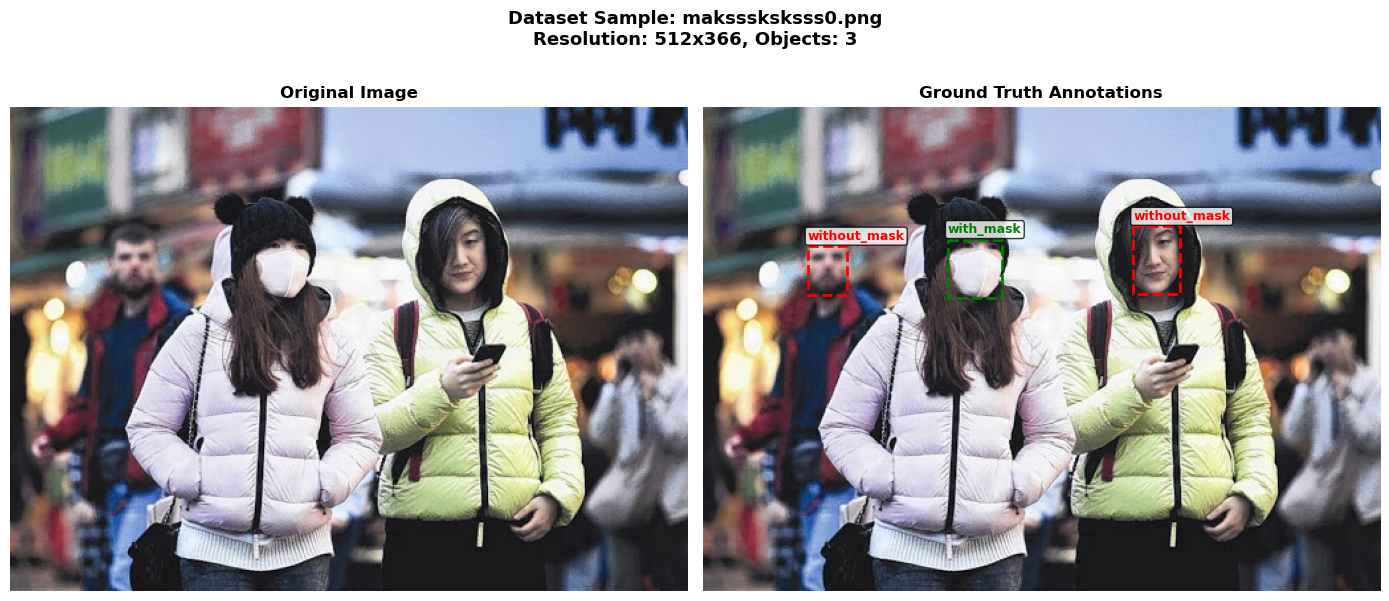

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_dataset_sample(dataset, idx=0):
    item = dataset[idx]
    _, img_rgb = load_image(item['img_path'])
    ann = item['annotation']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(img_rgb.astype(np.uint8))
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(img_rgb.astype(np.uint8))
    axes[1].set_title('Ground Truth Annotations', fontsize=12, fontweight='bold')

    colors = {'with_mask': 'green', 'without_mask': 'red', 'mask_weared_incorrect': 'orange'}
    
    for obj in ann['objects']:
        color = colors.get(obj['label'], 'blue')
        rect = Rectangle((obj['x'], obj['y']), obj['w'], obj['h'],
                        linewidth=2, edgecolor=color, facecolor='none', linestyle='--')
        axes[1].add_patch(rect)
        axes[1].text(obj['x'], obj['y']-5, obj['label'], 
                    color=color, fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    axes[1].axis('off')

    plt.suptitle(f"Dataset Sample: {ann['filename']}\nResolution: {ann['width']}x{ann['height']}, Objects: {len(ann['objects'])}", 
                 fontsize=13, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig('dataset_sample.png', dpi=150, bbox_inches='tight')
    plt.show()

def main():
    dataset = load_dataset(max_images=50)

    target_idx = 0
    for i, item in enumerate(dataset):
        if 'maksssksksss' in item['annotation']['filename']:
            target_idx = i
            break
    
    visualize_dataset_sample(dataset, idx=target_idx)

if __name__ == "__main__":
    main()